# Modelo de finishers — árbol / random forest

Objetivo: predecir `finisher_d` y `finisher_h` (finishers mujer/hombre) de una categoría de
una carrera a partir de sus características (distancia, tipo de modalidad, público,
ubicación, población del municipio...) y, cuando exista, del historial de la propia carrera.

Decisiones tomadas antes de escribir código, siguiendo las notas finales de
`EDA_finishers_carreras.ipynb`:

- **Dos modelos separados** (uno para `finisher_d`, otro para `finisher_h`), no uno
  multi-output: la participación femenina se comporta de forma muy distinta según
  distancia/modalidad (ver EDA, sección 3), así que tiene sentido poder ajustar cada
  modelo por separado.
- **Split train/test temporal, nunca por fila al azar**: la misma carrera en años
  consecutivos correlaciona al 0.90 en finishers (EDA, sección 4) — un split aleatorio
  dejaría la edición 2023 en train y la 2024 en test y el modelo parecería mucho mejor
  de lo que realmente es. Se entrena con años ≤ 2023 y se evalúa con 2024-2025 (2026 se
  excluye por ser el año en curso, con datos incompletos).
- **No se usa `Limpieza_outliers.ipynb`**: ese notebook decide, con razón, no recortar
  outliers para un árbol (son poco sensibles a la escala), así que como paso de "limpieza
  de outliers" no aporta nada aquí. Lo único útil que hacía — pasar el centinela
  `distancia == 0` a `NaN` — se repite más abajo directamente sobre `DF_TODAS.csv`, para
  no depender de un fichero (`DF_TODAS_SIN_OUTLIERS.csv`) que además está desactualizado
  respecto a la versión actual de `DF_TODAS.csv`.
- Se presta atención especial a la **población del municipio**: es la variable que, de
  forma aislada, más correlaciona con los objetivos en el EDA (aun así, por debajo de
  0.16), así que aquí no solo se incluye como feature — se comprueba su importancia real
  dentro del modelo entrenado, no se da por supuesta.

In [1]:
from pathlib import Path
import glob
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA_TODAS = Path("../../data/processed/union/DF_TODAS.csv")
df = pd.read_csv(RUTA_TODAS, encoding="utf-8-sig")
df["fecha"] = pd.to_datetime(df["fecha"])

print("Filas x columnas:", df.shape)
df.head()

Filas x columnas: (41650, 12)


,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,comarca,provincia
0,buscametas,Areta Trail Lasterketa,2026-07-25,Sábado,0.0,trail running,Absoluta/General,17.0,147.0,Areta,NaN,Álava
1,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,0.0,Ciclismo y btt,Absoluta/General,0.0,30.0,Ezcaray,NaN,La Rioja
2,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,93.0,Ciclismo y btt,Absoluta/General,2.0,38.0,Ezcaray,NaN,La Rioja
3,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,57.0,Ciclismo y btt,Absoluta/General,2.0,31.0,Ezcaray,NaN,La Rioja
4,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,42.0,Ciclismo y btt,Absoluta/General,2.0,10.0,Ezcaray,NaN,La Rioja


## Variables derivadas

`DF_TODAS.csv` solo guarda las 12 columnas comunes a las 10 fuentes — las derivadas
(`anyo`, `estacion`, `total_finishers`, `es_finde`) no se guardaron y hay que
recalcularlas aquí, tal como avisan las notas finales del EDA. Se recalculan
exactamente igual que allí.

In [2]:
MES_A_ESTACION = {
    12: "Invierno", 1: "Invierno", 2: "Invierno",
    3: "Primavera", 4: "Primavera", 5: "Primavera",
    6: "Verano", 7: "Verano", 8: "Verano",
    9: "Otoño", 10: "Otoño", 11: "Otoño",
}

df["anyo"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["estacion"] = df["mes"].map(MES_A_ESTACION)
df["total_finishers"] = df["finisher_d"] + df["finisher_h"]
df["es_finde"] = df["dia_semana"].isin(["Sábado", "Domingo"])

df[["fecha", "anyo", "estacion", "total_finishers", "es_finde"]].head()

,fecha,anyo,estacion,total_finishers,es_finde
0,2026-07-25,2026,Verano,164.0,True
1,2026-07-25,2026,Verano,30.0,True
2,2026-07-25,2026,Verano,40.0,True
3,2026-07-25,2026,Verano,33.0,True
4,2026-07-25,2026,Verano,12.0,True


## `distancia == 0` es un centinela, no un valor real

Igual que en `Limpieza_outliers.ipynb`: `distancia == 0` significa "no se pudo extraer
la distancia" en las 10 fuentes, no "carrera de 0 km". Se pasa a `NaN` y se guarda un
booleano `distancia_conocida` — el propio hecho de que la distancia se conozca o no
puede ser una señal (varía mucho por fuente/categoría) y así no se pierde esa
información al convertir a `NaN`. Se usa `np.nan`, no `pd.NA`, para que la columna se
quede en `float64`.

In [3]:
print("% de filas con distancia == 0, por fuente:")
print((df.groupby("fuente")["distancia"].apply(lambda s: (s == 0).mean() * 100)).round(1))

df["distancia_conocida"] = df["distancia"] != 0
df["distancia"] = df["distancia"].replace(0, np.nan)

print()
print("Filas con distancia ahora NaN:", df["distancia"].isna().sum(), "de", len(df))

% de filas con distancia == 0, por fuente:
fuente
buscametas          66.5
carreirasgalegas     1.1
ccnorte             65.7
cronofinisher       81.0
cruzandolameta      23.0
cursescat            4.5
iter5               34.2
mychip              13.0
sportmaniacs        65.4
xipgroc             63.1
Name: distancia, dtype: float64

Filas con distancia ahora NaN: 21577 de 41650


## Cruce con población del INE

Se repite el mismo cruce que en el EDA (nomenclátor INE 2025, municipio + provincia
normalizados). Cubre alrededor del 73% de las filas — el resto son sobre todo fuentes
donde `provincia` guarda la comunidad autónoma en vez de la provincia (Galicia,
Catalunya, Andalucía...), que no se puede resolver sin tocar esas fuentes.

In [4]:
def normalizar(texto):
    # Mayúsculas y sin acentos, para cruzar texto libre con el nomenclátor del INE.
    if pd.isna(texto):
        return None
    texto = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode("ascii")
    return texto.upper().strip()


PROVINCIA_INE = {
    1: ["Álava", "Araba", "Araba/Álava"], 2: ["Albacete"], 3: ["Alicante", "Alacant"],
    4: ["Almería"], 5: ["Ávila"], 6: ["Badajoz"], 7: ["Baleares", "Illes Balears", "Baleares (Illes)"],
    8: ["Barcelona"], 9: ["Burgos"], 10: ["Cáceres"], 11: ["Cádiz"], 12: ["Castellón", "Castelló"],
    13: ["Ciudad Real"], 14: ["Córdoba"], 15: ["La Coruña", "A Coruña"], 16: ["Cuenca"],
    17: ["Girona", "Gerona"], 18: ["Granada"], 19: ["Guadalajara"], 20: ["Guipúzcoa", "Gipuzkoa"],
    21: ["Huelva"], 22: ["Huesca"], 23: ["Jaén"], 24: ["León"], 25: ["Lleida", "Lérida"],
    26: ["La Rioja"], 27: ["Lugo"], 28: ["Madrid", "Comunidad de Madrid"], 29: ["Málaga"],
    30: ["Murcia", "Región de Murcia"], 31: ["Navarra"], 32: ["Ourense", "Orense"],
    33: ["Asturias", "Asturias / Asturies"], 34: ["Palencia"], 35: ["Las Palmas"],
    36: ["Pontevedra"], 37: ["Salamanca"], 38: ["Santa Cruz de Tenerife"], 39: ["Cantabria"],
    40: ["Segovia"], 41: ["Sevilla"], 42: ["Soria"], 43: ["Tarragona"], 44: ["Teruel"],
    45: ["Toledo"], 46: ["Valencia", "València"], 47: ["Valladolid"], 48: ["Vizcaya", "Bizkaia"],
    49: ["Zamora"], 50: ["Zaragoza"], 51: ["Ceuta"], 52: ["Melilla"],
}
PROVINCIA_A_CODIGO = {normalizar(n): c for c, ns in PROVINCIA_INE.items() for n in ns}

INE_DIR = Path("../../data/processed/union")
INE_PATH = glob.glob(str(INE_DIR / "DF_INE_Poblaciones_*.xlsx"))[0]
ine = pd.read_excel(INE_PATH, sheet_name="Sexo")

ine["_codigo"] = ine["Unidad Poblacional"].str.slice(0, 6)
ine_municipios = ine[ine["_codigo"] == "000000"].copy()
ine_municipios["municipio_norm"] = ine_municipios["Unidad Poblacional"].str.slice(6).str.strip().apply(normalizar)
ine_municipios["provincia_ine"] = ine_municipios["Provincia"].astype(int)
ine_municipios = ine_municipios.rename(columns={"Total 2025": "poblacion_total"})[
    ["municipio_norm", "provincia_ine", "poblacion_total"]
]
ine_municipios = ine_municipios.drop_duplicates(subset=["municipio_norm", "provincia_ine"], keep="first")

df["municipio_norm"] = df["municipio"].apply(normalizar)
df["provincia_ine"] = df["provincia"].apply(normalizar).map(PROVINCIA_A_CODIGO)
df = df.merge(ine_municipios, on=["municipio_norm", "provincia_ine"], how="left")

cobertura = 100 * df["poblacion_total"].notna().mean()
print(f"Filas con población cruzada: {df['poblacion_total'].notna().sum()} de {len(df)} ({cobertura:.1f}%)")

Filas con población cruzada: 30609 de 41650 (73.5%)


### Población desconocida: imputar, no descartar

Descartar el 27% de filas sin población cruzada sería tirar una cuarta parte de los
datos solo por un problema de normalización de texto en el origen. En vez de eso: se
guarda un booleano `poblacion_conocida` (para que el árbol pueda tratar distinto los
casos reales de los imputados) y se rellena el resto con la mediana global. Un
`RandomForestRegressor` de scikit-learn no admite `NaN` en los predictores, así que
alguna imputación es obligatoria pase lo que pase.

In [5]:
df["poblacion_conocida"] = df["poblacion_total"].notna()
mediana_poblacion = df["poblacion_total"].median()
df["poblacion_total"] = df["poblacion_total"].fillna(mediana_poblacion)

print(f"Población desconocida en {(~df['poblacion_conocida']).sum()} filas de {len(df)}, "
      f"imputada con la mediana global ({mediana_poblacion:,.0f} hab.)")

Población desconocida en 11041 filas de 41650, imputada con la mediana global (15,567 hab.)


También hay que imputar `distancia` (quedó en `NaN` donde antes había el
centinela `0`): se usa la mediana dentro de cada `tipo_modalidad`, porque la escala
típica es muy distinta entre disciplinas (una `Ciclismo y btt` y una `Infantil` no
tienen distancias comparables).

In [6]:
df["distancia"] = df.groupby("tipo_modalidad")["distancia"].transform(lambda s: s.fillna(s.median()))
df["distancia"] = df["distancia"].fillna(df["distancia"].median())  # por si algún grupo fuera 100% NaN

print("Nulos en distancia tras imputar:", df["distancia"].isna().sum())

Nulos en distancia tras imputar: 0


## El predictor más fuerte: el historial de la propia carrera

El EDA (sección 4) encontró una correlación de 0.90 entre los finishers de una carrera
un año y los del año anterior — con diferencia, la señal más fuerte de todo el
análisis, muy por encima de cualquier variable descriptiva. Aquí se construye ese
historial a nivel de fila (no solo de carrera): para cada `fuente` + carrera
(nombre normalizado, sin ordinal de edición ni año) + `publico`, se busca el valor de
`finisher_d`/`finisher_h` del año inmediatamente anterior (solo años consecutivos, para
no mezclar ediciones con un hueco de por medio).

In [7]:
def _normalizar_base(nombre):
    if pd.isna(nombre):
        return None
    t = unicodedata.normalize("NFKD", str(nombre)).encode("ascii", "ignore").decode("ascii").upper()
    t = re.sub(r"[^A-Z0-9]+", " ", t)
    t = re.sub(r"^\s*(?:[IVXLC]{1,6}|\d{1,3}(?:A|O|ER|ERA)?)\b\s*", "", t)  # ordinal inicial
    t = re.sub(r"\b(19|20)\d{2}\b", "", t)  # año suelto
    return re.sub(r"\s{2,}", " ", t).strip()


df["nombre_base"] = df["nombre_carrera"].apply(_normalizar_base)

CLAVE_CARRERA = ["fuente", "nombre_base", "publico"]
historico = (
    df[CLAVE_CARRERA + ["anyo", "finisher_d", "finisher_h"]]
    .dropna(subset=["finisher_d", "finisher_h"])
    .groupby(CLAVE_CARRERA + ["anyo"], as_index=False)[["finisher_d", "finisher_h"]]
    .sum()
    .sort_values(CLAVE_CARRERA + ["anyo"])
)
historico["anyo_anterior"] = historico.groupby(CLAVE_CARRERA)["anyo"].shift(1)
historico["finisher_d_anterior"] = historico.groupby(CLAVE_CARRERA)["finisher_d"].shift(1)
historico["finisher_h_anterior"] = historico.groupby(CLAVE_CARRERA)["finisher_h"].shift(1)
historico = historico[historico["anyo"] - historico["anyo_anterior"] == 1]

df = df.merge(
    historico[CLAVE_CARRERA + ["anyo", "finisher_d_anterior", "finisher_h_anterior"]],
    on=CLAVE_CARRERA + ["anyo"],
    how="left",
)
df["tiene_historial"] = df["finisher_d_anterior"].notna()

print(f"Filas con historial de la edición anterior (misma carrera y categoría): "
      f"{df['tiene_historial'].sum()} de {len(df)} ({100 * df['tiene_historial'].mean():.1f}%)")

Filas con historial de la edición anterior (misma carrera y categoría): 12132 de 41650 (29.1%)


## Para las carreras SIN historial: comparables por grupo similar, no la media global

El objetivo no es solo predecir bien las ediciones de carreras que ya conocemos —
sobre todo interesa poder predecir con confianza una **carrera nueva**. Ahí es
justo donde el modelo flaqueaba: sin historial propio, `finisher_d_anterior`/
`finisher_h_anterior` no tenían ningún valor real que ofrecer, y rellenarlos con
la mediana global (un solo número para las 41.650 filas) no distingue nada entre,
por ejemplo, una maratón de road running en Barcelona y una carrera infantil de
5 km en un pueblo pequeño.

En vez de eso: para cada fila se busca la mediana (en escala `log1p`, para no
dejarse arrastrar por los eventos gigantes) de `finisher_d`/`finisher_h` entre
carreras **comparables** — misma `tipo_modalidad` + `publico` + `provincia` +
tramo de `distancia` — y si ese grupo tiene muy pocas muestras, se retrocede a un
grupo más amplio (se quita primero `provincia`, luego `publico`, y en último caso
solo se exige `tipo_modalidad`). Los estadísticos de cada grupo se calculan
**solo con años de train (≤ 2023)**, y con *leave-one-out* dentro del propio train
(cada fila se compara con las demás de su grupo, nunca consigo misma) para no
inflar artificialmente su propia estimación — si no se hiciera así, una fila de
train "vería" su propio valor camuflado dentro de la media del grupo.

Se guarda también `nivel_comparable` (0 = coincidencia más específica, 4 =
solo hizo falta la disciplina): es una señal de cuánto fiarse de la estimación,
igual que `distancia_conocida`/`poblacion_conocida` más arriba.

In [8]:
DISTANCIA_BINS = [-0.01, 5, 10, 21, 42, 100, np.inf]
DISTANCIA_ETIQUETAS = ["≤5km", "5-10km", "10-21km", "21-42km", "42-100km", ">100km"]
df["distancia_bin"] = pd.cut(df["distancia"], bins=DISTANCIA_BINS, labels=DISTANCIA_ETIQUETAS)

# Igual que en el split final: años <= 2023 y con finisher_d/finisher_h reales.
MASK_TRAIN_VALIDO = (df["anyo"] <= 2023) & df["finisher_d"].notna() & df["finisher_h"].notna()

NIVELES_COMPARABLES = [
    ["tipo_modalidad", "publico", "provincia", "distancia_bin"],
    ["tipo_modalidad", "publico", "distancia_bin"],
    ["tipo_modalidad", "distancia_bin"],
    ["tipo_modalidad"],
]
MIN_MUESTRAS_GRUPO = 20
COLUMNAS_OBJETIVO = ["finisher_d", "finisher_h"]


def construir_features_comparables():
    logs = {col: np.log1p(df[col]) for col in COLUMNAS_OBJETIVO}
    estimaciones = {col: pd.Series(np.nan, index=df.index) for col in COLUMNAS_OBJETIVO}
    nivel_usado = pd.Series(len(NIVELES_COMPARABLES), index=df.index)
    pendiente = pd.Series(True, index=df.index)

    for nivel, claves in enumerate(NIVELES_COMPARABLES):
        base = df.loc[MASK_TRAIN_VALIDO, claves].copy()
        for col in COLUMNAS_OBJETIVO:
            base[f"_log_{col}"] = logs[col][MASK_TRAIN_VALIDO]
        agregados = {f"_log_{col}": ["sum", "count"] for col in COLUMNAS_OBJETIVO}
        stats = base.groupby(claves, observed=True).agg(agregados)
        stats.columns = ["_".join(c) for c in stats.columns]
        stats = stats.reset_index()

        filas_pendientes = df.loc[pendiente, claves].reset_index().rename(columns={"index": "_idx"})
        unido = filas_pendientes.merge(stats, on=claves, how="left").set_index("_idx")

        # El nº de muestras del grupo es el mismo para "finisher_d" y "finisher_h"
        # (depende solo de qué filas caen en el grupo, no del objetivo).
        cuenta_col = f"_log_{COLUMNAS_OBJETIVO[0]}_count"
        unido[cuenta_col] = unido[cuenta_col].fillna(0)
        es_propio = MASK_TRAIN_VALIDO.reindex(unido.index).fillna(False)
        cuenta_ajustada = unido[cuenta_col] - es_propio.astype(int)  # leave-one-out

        validos = cuenta_ajustada >= MIN_MUESTRAS_GRUPO
        idx_validos = unido.index[validos]

        for col in COLUMNAS_OBJETIVO:
            suma = unido[f"_log_{col}_sum"].fillna(0.0)
            valor_propio = logs[col].reindex(unido.index).fillna(0.0)
            suma_ajustada = suma - np.where(es_propio, valor_propio, 0.0)  # leave-one-out
            media = suma_ajustada[validos] / cuenta_ajustada[validos]
            estimaciones[col].loc[idx_validos] = media.to_numpy()

        nivel_usado.loc[idx_validos] = nivel
        pendiente.loc[idx_validos] = False

    for col in COLUMNAS_OBJETIVO:
        media_global = logs[col][MASK_TRAIN_VALIDO].mean()  # fallback si ni la disciplina sola tiene 20 muestras
        estimaciones[col].loc[pendiente] = media_global
        df[f"{col}_comparable"] = np.expm1(estimaciones[col])

    df["nivel_comparable"] = nivel_usado.astype(int)


construir_features_comparables()

print("Filas resueltas por nivel (0=modalidad+público+provincia+distancia, ..., 4=fallback global):")
print(df["nivel_comparable"].value_counts().sort_index())

Filas resueltas por nivel (0=modalidad+público+provincia+distancia, ..., 4=fallback global):
nivel_comparable
0    28853
1    11954
2      734
3      109
Name: count, dtype: int64


Ahora sí, `finisher_d_anterior`/`finisher_h_anterior` se rellenan con la
estimación por comparables en vez de con un número fijo — cada carrera sin
historial recibe un punto de partida ajustado a su propio perfil, no al
promedio de todo el dataset.

In [9]:
df["finisher_d_anterior"] = df["finisher_d_anterior"].fillna(df["finisher_d_comparable"])
df["finisher_h_anterior"] = df["finisher_h_anterior"].fillna(df["finisher_h_comparable"])

print("Nulos restantes en finisher_d_anterior/finisher_h_anterior:",
      df[["finisher_d_anterior", "finisher_h_anterior"]].isna().sum().sum())

Nulos restantes en finisher_d_anterior/finisher_h_anterior: 0


## Construcción de `X`/`y`

Variables usadas:

- **Numéricas**: `distancia`, `anyo` (para capturar la tendencia temporal que el EDA
  encontró en la participación femenina), `poblacion_total`, `finisher_d_anterior`/
  `finisher_h_anterior` (historial propio, o la estimación por comparables cuando no
  existe), `finisher_d_comparable`/`finisher_h_comparable` (la estimación por
  comparables **siempre**, incluso cuando sí hay historial propio — deja que el árbol
  compare "lo que pasó realmente" con "lo típico para una carrera así"), y
  `nivel_comparable` (cuán específico fue el grupo usado para esa estimación).
- **Booleanas**: `es_finde` (se usa en vez de `dia_semana` porque en el EDA iban casi
  calcadas — 0.80 de correlación — y no aporta meter las dos), `distancia_conocida`,
  `poblacion_conocida`, `tiene_historial`.
- **Categóricas (one-hot)**: `tipo_modalidad`, `publico`, `estacion`, `provincia`
  (con "Desconocida" para los nulos, en vez de descartar esas filas).

Se descartan las filas sin `finisher_d`/`finisher_h` reales (las 2.474 marcadas como
`NaN` en el EDA porque eran categorías nunca capturadas, no carreras de 0 personas) —
no tienen etiqueta para entrenar ni para evaluar.

In [10]:
FEATURES_NUM = [
    "distancia", "anyo", "poblacion_total",
    "finisher_d_anterior", "finisher_h_anterior",
    "finisher_d_comparable", "finisher_h_comparable", "nivel_comparable",
]
FEATURES_BOOL = ["es_finde", "distancia_conocida", "poblacion_conocida", "tiene_historial"]
FEATURES_CAT = ["tipo_modalidad", "publico", "estacion", "provincia"]

modelo_df = df.dropna(subset=["finisher_d", "finisher_h"]).copy()
modelo_df["provincia"] = modelo_df["provincia"].fillna("Desconocida")

X = pd.get_dummies(modelo_df[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT], columns=FEATURES_CAT)
y_d = modelo_df["finisher_d"]
y_h = modelo_df["finisher_h"]

print("Filas para modelar:", len(modelo_df), " | nº de features tras one-hot:", X.shape[1])

Filas para modelar: 39176  | nº de features tras one-hot: 105


## Split train/test temporal

Tal como pide el EDA: nada de partir filas al azar. Se entrena con años ≤ 2023 y se
evalúa con 2024-2025; 2026 se excluye por ser el año en curso (datos incompletos hasta
la fecha de hoy).

In [11]:
anyo_split = modelo_df["anyo"]
train_mask = (anyo_split <= 2023).to_numpy()
test_mask = anyo_split.isin([2024, 2025]).to_numpy()

print(f"Train (años <= 2023): {train_mask.sum()} filas")
print(f"Test (años 2024-2025): {test_mask.sum()} filas")
print(f"Excluidas (año 2026, en curso): {(~train_mask & ~test_mask).sum()} filas")

X_train, X_test = X[train_mask], X[test_mask]
y_d_train, y_d_test = y_d[train_mask], y_d[test_mask]
y_h_train, y_h_test = y_h[train_mask], y_h[test_mask]

Train (años <= 2023): 28140 filas
Test (años 2024-2025): 9138 filas
Excluidas (año 2026, en curso): 1898 filas


## Baseline: "este año será como el anterior"

Antes de entrenar nada, conviene saber si el árbol aporta algo por encima de la señal
más simple posible: usar directamente el valor de la edición anterior cuando existe (o
la mediana de train si la carrera no tiene historial). Si el random forest no supera
esto, no está aportando valor real.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"  {nombre}: MAE={mae:6.1f}   RMSE={rmse:6.1f}   R²={r2:.3f}")
    return mae, rmse, r2


mediana_d_train = y_d_train.median()
mediana_h_train = y_h_train.median()

tiene_hist_test = modelo_df.loc[test_mask, "tiene_historial"].to_numpy()
baseline_d_test = np.where(tiene_hist_test, modelo_df.loc[test_mask, "finisher_d_anterior"], mediana_d_train)
baseline_h_test = np.where(tiene_hist_test, modelo_df.loc[test_mask, "finisher_h_anterior"], mediana_h_train)

print("Baseline (histórico del año anterior, o mediana de train si no hay):")
evaluar(y_d_test, baseline_d_test, "finisher_d")
evaluar(y_h_test, baseline_h_test, "finisher_h")

Baseline (histórico del año anterior, o mediana de train si no hay):
  finisher_d: MAE=  56.7   RMSE= 202.0   R²=0.086
  finisher_h: MAE= 126.3   RMSE= 376.2   R²=-0.172


(126.31626176406216, 376.2489897053846, -0.17165006756726275)

## Ajuste de hiperparámetros — validación temporal, no k-fold al azar

Igual que en el split train/test, un `GridSearchCV` con k-fold aleatorio estaría
mezclando en el mismo pliegue ediciones consecutivas de la misma carrera (correlación
0.90) y elegiría hiperparámetros que parecen mejores de lo que son en producción. En su
lugar se hace una validación **walk-forward** dentro del propio train (años ≤ 2023):
para cada año candidato de validación, se entrena solo con los años anteriores y se
valida con ese año — igual que se evaluará luego de verdad contra 2024-2025. Se
descartan como año de validación los años con muy pocas filas (< 500), y de los que
quedan solo se usan los **5 más recientes**: son los más representativos del volumen de
datos actual y evitan que el ajuste tarde demasiado sin aportar mucha más información
(los años más antiguos tienen bastantes menos filas por fuente).

El conjunto de test (2024-2025) no se toca en ningún momento de este ajuste — sigue
siendo una evaluación final limpia.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

MIN_FILAS_ANYO_VALIDACION = 500
MAX_PLIEGUES = 5

anyo_train_arr = modelo_df.loc[train_mask, "anyo"].to_numpy()
anyos_candidatos = sorted(y for y in np.unique(anyo_train_arr) if (anyo_train_arr == y).sum() >= MIN_FILAS_ANYO_VALIDACION)

cv_walk_forward = []
for anyo_val in anyos_candidatos:
    idx_val = np.where(anyo_train_arr == anyo_val)[0]
    idx_train = np.where(anyo_train_arr < anyo_val)[0]
    if len(idx_train) >= MIN_FILAS_ANYO_VALIDACION:
        cv_walk_forward.append((anyo_val, idx_train, idx_val))

cv_walk_forward = cv_walk_forward[-MAX_PLIEGUES:]
print(f"Pliegues walk-forward: validando en los años {[a for a, _, _ in cv_walk_forward]}")
cv_walk_forward = [(idx_train, idx_val) for _, idx_train, idx_val in cv_walk_forward]

PARAM_GRID = {
    "n_estimators": [150, 300],
    "max_depth": [None, 15],
    "min_samples_leaf": [2, 5],
}


def buscar_mejores_parametros(X_tr, y_tr, nombre):
    busqueda = GridSearchCV(
        RandomForestRegressor(random_state=0, n_jobs=1),
        PARAM_GRID,
        cv=cv_walk_forward,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    busqueda.fit(X_tr, y_tr)
    print(f"Mejores hiperparámetros para {nombre}: {busqueda.best_params_} "
          f"(MAE walk-forward: {-busqueda.best_score_:.1f})")
    return busqueda.best_params_


mejores_d = buscar_mejores_parametros(X_train, y_d_train, "finisher_d")
mejores_h = buscar_mejores_parametros(X_train, y_h_train, "finisher_h")

Pliegues walk-forward: validando en los años [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


Mejores hiperparámetros para finisher_d: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300} (MAE walk-forward: 79.1)


Mejores hiperparámetros para finisher_h: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300} (MAE walk-forward: 100.0)


## Random forest final

Un modelo por objetivo, como se decidió: uno para `finisher_d`, otro para
`finisher_h`, cada uno con los hiperparámetros elegidos por validación walk-forward y
entrenado sobre todo el train (años ≤ 2023).

In [14]:
rf_d = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_d)
rf_d.fit(X_train, y_d_train)
pred_d = rf_d.predict(X_test)

rf_h = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_h)
rf_h.fit(X_train, y_h_train)
pred_h = rf_h.predict(X_test)

print("Random forest (hiperparámetros ajustados):")
evaluar(y_d_test, pred_d, "finisher_d")
evaluar(y_h_test, pred_h, "finisher_h")

Random forest (hiperparámetros ajustados):
  finisher_d: MAE=  46.3   RMSE= 187.9   R²=0.208
  finisher_h: MAE=  88.1   RMSE= 290.7   R²=0.300


(88.08374255441672, 290.7325130191978, 0.3004247417067436)

## Importancia de variables — ¿pesa realmente la población?

Aquí se comprueba empíricamente lo que se intuía: que la población del municipio
debería tener mucho que ver con la predicción. En el EDA, tomada sola, era de las
variables individuales con más correlación (aun así, por debajo de 0.16) — pero eso no
garantiza que siga pesando así dentro de un modelo que ya tiene acceso al historial de
la propia carrera, que es mucho más fuerte. La importancia de features del random
forest lo deja ver directamente, sin dar nada por supuesto.

Top 15 variables más importantes para finisher_d:
finisher_d_anterior      0.512962
finisher_d_comparable    0.204995
distancia                0.053111
finisher_h_comparable    0.039164
poblacion_total          0.034088
anyo                     0.032988
provincia_Barcelona      0.032794
finisher_h_anterior      0.031051
provincia_A Coruña       0.012252
es_finde                 0.008945
distancia_conocida       0.008863
provincia_Asturias       0.006157
estacion_Verano          0.003310
estacion_Otoño           0.003204
provincia_Valencia       0.001818

Top 15 variables más importantes para finisher_h:
finisher_h_anterior      0.314618
finisher_h_comparable    0.192985
finisher_d_comparable    0.108783
finisher_d_anterior      0.107540
poblacion_total          0.084416
provincia_Sevilla        0.035009
anyo                     0.032206
distancia                0.026956
estacion_Invierno        0.013208
es_finde                 0.010932
provincia_Valencia       0.010707
distancia_conoc

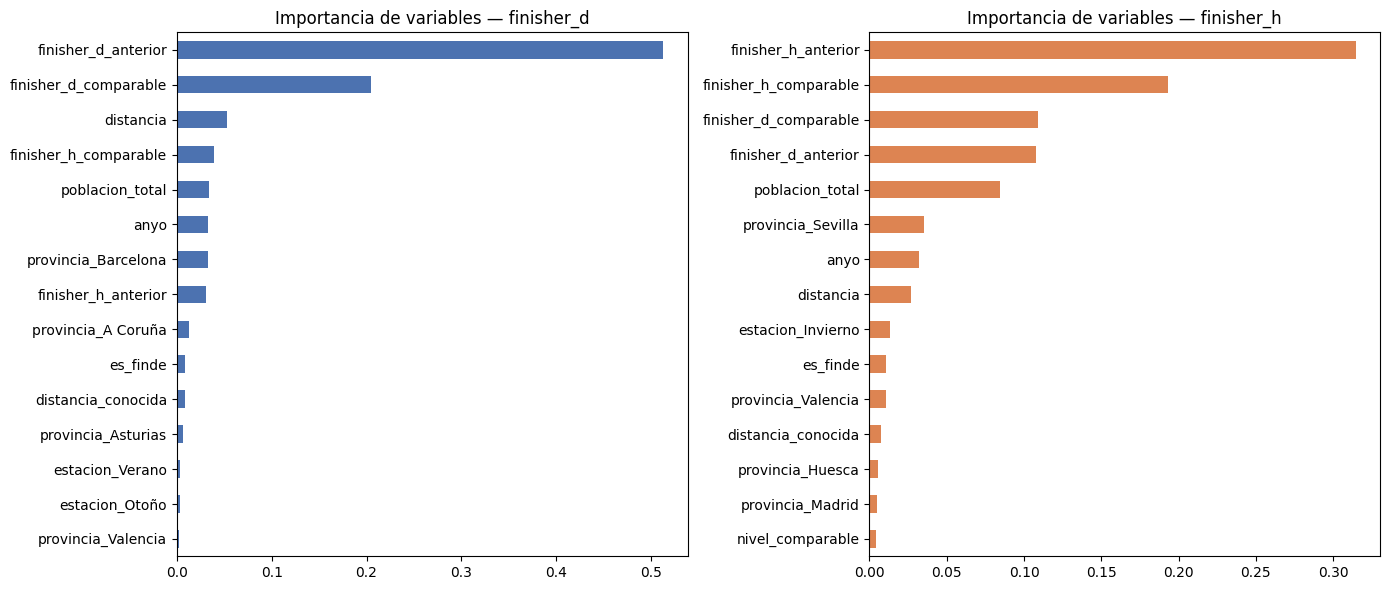

In [15]:
def importancias(modelo, nombre):
    imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"Top 15 variables más importantes para {nombre}:")
    print(imp.head(15).to_string())
    print()
    return imp


imp_d = importancias(rf_d, "finisher_d")
imp_h = importancias(rf_h, "finisher_h")

for nombre, imp in [("finisher_d", imp_d), ("finisher_h", imp_h)]:
    pos = list(imp.index).index("poblacion_total") + 1
    print(f"'poblacion_total' en {nombre}: puesto {pos} de {len(imp)}, "
          f"importancia={imp['poblacion_total']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_d.head(15).sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Importancia de variables — finisher_d")
imp_h.head(15).sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Importancia de variables — finisher_h")
plt.tight_layout()
plt.show()

## ¿Cuánto depende todo esto de tener historial?

El historial de la edición anterior es, con diferencia, el predictor más fuerte. Vale
la pena separar el rendimiento en test entre carreras que sí tienen historial (la
mayoría de los casos "fáciles") y las que no (carreras nuevas o con un hueco de años,
donde el modelo tiene que apoyarse solo en `distancia`/`publico`/`población`/etc.) —
es el escenario donde de verdad se pone a prueba si esas variables descriptivas
aportan algo.

In [16]:
print("Test — SOLO carreras CON historial de la edición anterior:")
evaluar(y_d_test[tiene_hist_test], pred_d[tiene_hist_test], "finisher_d")
evaluar(y_h_test[tiene_hist_test], pred_h[tiene_hist_test], "finisher_h")

print()
print("Test — SOLO carreras SIN historial (nuevas o con hueco de años):")
evaluar(y_d_test[~tiene_hist_test], pred_d[~tiene_hist_test], "finisher_d")
evaluar(y_h_test[~tiene_hist_test], pred_h[~tiene_hist_test], "finisher_h")

Test — SOLO carreras CON historial de la edición anterior:
  finisher_d: MAE=  49.0   RMSE= 157.0   R²=0.453
  finisher_h: MAE=  91.3   RMSE= 218.9   R²=0.511

Test — SOLO carreras SIN historial (nuevas o con hueco de años):
  finisher_d: MAE=  44.5   RMSE= 205.4   R²=0.046
  finisher_h: MAE=  86.0   RMSE= 328.9   R²=0.201


(85.9816271041173, 328.8766626182277, 0.20056511853923598)

## Notas finales

- El baseline "este año = el año anterior" ya es fuerte por sí solo (confirma la
  correlación de 0.90 del EDA); el valor real del random forest hay que juzgarlo sobre
  todo en el subconjunto **sin** historial, y comparando siempre contra ese baseline,
  no contra "acertar el número exacto".
- La imputación de `poblacion_total` (27% de las filas) y de `distancia` (por el
  centinela `0`) es una limitación real heredada de los datos de origen — antes de fiarse
  de la importancia de esas variables conviene tener en cuenta que una parte de sus
  valores son "rellenos", no observaciones.
- El problema de las carreras de ciclismo de fondo mal etiquetadas como `road running`
  (`Mallorca 312`, `MOZARABE BIKE RACE`...) se corrigió en origen, en
  `Limpieza_sportmaniacs.ipynb`/`Limpieza_cruzandolameta.ipynb`, y `DF_TODAS.csv` ya
  incorpora la corrección — no hace falta ningún ajuste aquí.
- Los hiperparámetros del random forest ya se ajustan con validación walk-forward por
  año (ver sección anterior), no con un `GridSearchCV` de k-fold aleatorio.
- Para las carreras sin historial propio ya no se usa un único valor global: se estima
  por comparables (misma modalidad/público/provincia/distancia, con retroceso a grupos
  más amplios) — ver la sección "Para las carreras SIN historial". El rendimiento real
  de esta mejora hay que juzgarlo específicamente en el desglose "test sin historial"
  de más arriba, comparándolo con la versión anterior (mediana global).
- La fuente `rockthesport` (`Scraper_rockthesport.ipynb`) todavía no está integrada en
  `DF_TODAS.csv` — cuando lo esté, este notebook se puede volver a ejecutar sin cambios
  (parte siempre de `DF_TODAS.csv` recién generado).
- Próximo paso natural si se quiere seguir mejorando el caso "carrera nueva": usar
  variables geográficas más finas que `provincia` (comarca, o directamente distancia
  en km al evento comparable más cercano), ya que ahora mismo el retroceso a nivel
  "provincia" es bastante amplio en zonas con pocas carreras de una disciplina
  concreta.